# Stage 3 - Circuit design

In [1]:
import os, sys
ROOT = os.getcwd()
while not os.path.exists(os.path.join(ROOT, "src", "config.py")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError("Project root (folder containing src/) not found")
    ROOT = parent
os.chdir(ROOT)
sys.path.insert(0, ROOT)
os.makedirs("results/figures", exist_ok=True)

In [2]:
import os
import json
import numpy as np
from scipy.stats import norm

p0, rho, z_max = 0.25, 0.027, 3.0

def pd_given_z(z, p0=p0, rho=rho):
    numerator = norm.ppf(p0) - np.sqrt(rho) * z
    denominator = np.sqrt(1 - rho)
    return norm.cdf(numerator / denominator)

try:
    with open("results/quantum_encoding_params.json") as f:
        enc = json.load(f)
    print("Loaded results/quantum_encoding_params.json from Stage 02.")
except FileNotFoundError:
    print("Stage 02 output not found -- recomputing alpha, beta, alpha_tilde, beta_tilde locally.")
    z_fit = np.linspace(-z_max, z_max, 400)
    theta_fit = np.arcsin(np.sqrt(pd_given_z(z_fit)))
    alpha, beta = np.polyfit(z_fit, theta_fit, 1)
    enc = {"register_adapted": {}}
    for n_qubits in (2, 3):
        n_bins = 2 ** n_qubits
        slope = (2 * z_max) / (n_bins - 1)
        a_tilde = alpha * slope
        b_tilde = beta - alpha * z_max
        enc["register_adapted"][f"{n_qubits}_qubit"] = {"alpha_tilde": a_tilde, "beta_tilde": b_tilde}

alpha_tilde_2q = enc["register_adapted"]["2_qubit"]["alpha_tilde"]
beta_tilde_2q  = enc["register_adapted"]["2_qubit"]["beta_tilde"]
alpha_tilde_3q = enc["register_adapted"]["3_qubit"]["alpha_tilde"]
beta_tilde_3q  = enc["register_adapted"]["3_qubit"]["beta_tilde"]

print(f"\n2-qubit register:  alpha_tilde = {alpha_tilde_2q:.6f}   beta_tilde = {beta_tilde_2q:.6f}")
print(f"3-qubit register:  alpha_tilde = {alpha_tilde_3q:.6f}   beta_tilde = {beta_tilde_3q:.6f}")

Loaded results/quantum_encoding_params.json from Stage 02.

2-qubit register:  alpha_tilde = -0.120979   beta_tilde = 0.705516
3-qubit register:  alpha_tilde = -0.051848   beta_tilde = 0.705516


In [3]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

def build_gci_circuit(n_z_qubits, alpha_tilde, beta_tilde, add_measurement=True, add_barrier=True):
    """Builds the full GCI quantum circuit:
        - z-register (qubits 0..n_z_qubits-1): Ry(theta_i) ansatz + CNOT star-entangler
        - asset qubit (qubit n_z_qubits): unconditional Ry(2*beta_tilde) +
          n_z_qubits controlled-Ry(2*alpha_tilde*2^k) gates, one per register qubit

    Returns: (QuantumCircuit, list_of_theta_Parameters)
    """
    n_total = n_z_qubits + 1
    asset_qubit = n_z_qubits
    qc = QuantumCircuit(n_total, n_total, name=f"GCI_{n_z_qubits}q_register")

    # --- Block 1: Gaussian-loading ansatz on the z-register (trainable) ---
    thetas = [Parameter(f"theta_{i}") for i in range(n_z_qubits)]
    for i in range(n_z_qubits):
        qc.ry(thetas[i], i)
    for i in range(1, n_z_qubits):
        qc.cx(0, i)   # star-pattern entangler, control = qubit 0

    if add_barrier:
        qc.barrier()

    # --- Block 2: asset-qubit conditional encoding (fixed, analytic) ---
    qc.ry(2 * beta_tilde, asset_qubit)
    for k in range(n_z_qubits):
        qc.cry(2 * alpha_tilde * (2 ** k), k, asset_qubit)

    if add_measurement:
        qc.measure(range(n_total), range(n_total))

    return qc, thetas

qc_2q, thetas_2q = build_gci_circuit(2, alpha_tilde_2q, beta_tilde_2q)
qc_3q, thetas_3q = build_gci_circuit(3, alpha_tilde_3q, beta_tilde_3q)

print("2-qubit z-register circuit -- parameters:", thetas_2q)
print("3-qubit z-register circuit -- parameters:", thetas_3q)

2-qubit z-register circuit -- parameters: [Parameter(theta_0), Parameter(theta_1)]
3-qubit z-register circuit -- parameters: [Parameter(theta_0), Parameter(theta_1), Parameter(theta_2)]


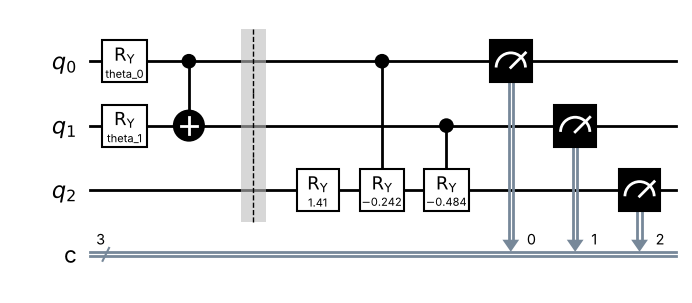

In [4]:
# ---- Draw both circuits ----
fig1 = qc_2q.draw('mpl', style={'name': 'bw'})
fig1.savefig('results/figures/stage03_circuit_2q_register.png', dpi=150, bbox_inches='tight')
fig1

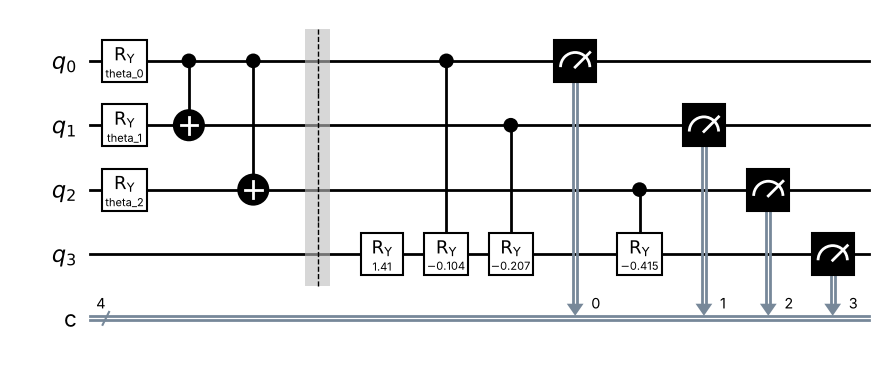

In [5]:
fig2 = qc_3q.draw('mpl', style={'name': 'bw'})
fig2.savefig('results/figures/stage03_circuit_3q_register.png', dpi=150, bbox_inches='tight')
fig2

In [6]:
for label, qc in [("2-qubit z-register (3 total qubits)", qc_2q),
                   ("3-qubit z-register (4 total qubits)", qc_3q)]:
    print(f"--- {label} ---")
    print(f"  Depth       : {qc.depth()}")
    print(f"  Gate counts : {dict(qc.count_ops())}")
    print()

--- 2-qubit z-register (3 total qubits) ---
  Depth       : 6
  Gate counts : {'ry': 3, 'measure': 3, 'cry': 2, 'cx': 1, 'barrier': 1}

--- 3-qubit z-register (4 total qubits) ---
  Depth       : 8
  Gate counts : {'ry': 4, 'measure': 4, 'cry': 3, 'cx': 2, 'barrier': 1}



In [7]:
from qiskit.quantum_info import Statevector

def asset_probability_for_basis_state(n_z_qubits, b, alpha_tilde, beta_tilde):
    """Prepares the z-register in basis state |b>, applies only the asset-encoding
    block (no ansatz), and returns the exact P(asset qubit = 1) via statevector simulation.
    """
    n_total = n_z_qubits + 1
    asset_qubit = n_z_qubits
    qc = QuantumCircuit(n_total)

    # prepare register in basis state b via X gates on the appropriate qubits
    for k in range(n_z_qubits):
        if (b >> k) & 1:
            qc.x(k)

    # asset-encoding block only (no measurement -- we want the exact statevector)
    qc.ry(2 * beta_tilde, asset_qubit)
    for k in range(n_z_qubits):
        qc.cry(2 * alpha_tilde * (2 ** k), k, asset_qubit)

    sv = Statevector.from_instruction(qc)
    p0_asset, p1_asset = sv.probabilities(qargs=[asset_qubit])
    return p1_asset

def discretize_z(n_qubits, z_max=z_max):
    n_bins = 2 ** n_qubits
    b = np.arange(n_bins)
    return -z_max + (2 * z_max) * b / (n_bins - 1)

for n_qubits, a_tilde, b_tilde in [(2, alpha_tilde_2q, beta_tilde_2q),
                                    (3, alpha_tilde_3q, beta_tilde_3q)]:
    z_grid = discretize_z(n_qubits)
    print(f"=== {n_qubits}-qubit register: Qiskit circuit vs. Stage 02's NumPy result ===")
    print(f"{'b':>3} | {'z(b)':>7} | {'sin^2(a~b+b~)':>14} | {'Qiskit statevector':>18} | {'match?':>7}")
    print("-" * 62)
    for b in range(2 ** n_qubits):
        formula_pred = np.sin(a_tilde * b + b_tilde) ** 2
        qiskit_pred = asset_probability_for_basis_state(n_qubits, b, a_tilde, b_tilde)
        match = np.isclose(formula_pred, qiskit_pred, atol=1e-9)
        print(f"{b:3d} | {z_grid[b]:7.3f} | {formula_pred:14.6f} | {qiskit_pred:18.6f} | {str(match):>7}")
    print()

=== 2-qubit register: Qiskit circuit vs. Stage 02's NumPy result ===
  b |    z(b) |  sin^2(a~b+b~) | Qiskit statevector |  match?
--------------------------------------------------------------
  0 |  -3.000 |       0.420457 |           0.420457 |    True
  1 |  -1.000 |       0.304498 |           0.304498 |    True
  2 |   1.000 |       0.199929 |           0.199929 |    True
  3 |   3.000 |       0.112841 |           0.112841 |    True

=== 3-qubit register: Qiskit circuit vs. Stage 02's NumPy result ===
  b |    z(b) |  sin^2(a~b+b~) | Qiskit statevector |  match?
--------------------------------------------------------------
  0 |  -3.000 |       0.420457 |           0.420457 |    True
  1 |  -2.143 |       0.369789 |           0.369789 |    True
  2 |  -1.286 |       0.320519 |           0.320519 |    True
  3 |  -0.429 |       0.273177 |           0.273177 |    True
  4 |   0.429 |       0.228272 |           0.228272 |    True
  5 |   1.286 |       0.186286 |           0.186286 |

In [8]:
def bind_and_get_joint_distribution(qc, thetas, theta_values, n_z_qubits):
    """Binds numeric values to the ansatz parameters and returns the exact joint
    probability distribution over (z-register basis state, asset outcome),
    via statevector simulation (no measurement gates -- we build a fresh copy without them).
    """
    qc_no_meas = qc.remove_final_measurements(inplace=False)
    bound = qc_no_meas.assign_parameters(dict(zip(thetas, theta_values)))
    sv = Statevector.from_instruction(bound)
    probs = sv.probabilities_dict()
    return probs

# Placeholder angles -- NOT yet trained, just illustrative (arbitrary values)
placeholder_2q = [np.pi / 2, 2.0]
probs_2q = bind_and_get_joint_distribution(qc_2q, thetas_2q, placeholder_2q, n_z_qubits=2)

print("Placeholder (untrained) 2-qubit-register circuit -- joint distribution:")
print(f"{'bitstring (asset,q1,q0)':>26} | {'probability':>12}")
print("-" * 43)
for bitstring, p in sorted(probs_2q.items()):
    print(f"{bitstring:>26} | {p:12.4f}")

print("""
Reading the bitstring: Qiskit prints bits as 'q_(n-1) ... q_1 q_0', so the LEFTMOST
character is the asset qubit and the two RIGHTMOST characters are (q1, q0) of the z-register.
E.g. '101' means asset=1, q1=0, q0=1  ->  z-register in basis state b=1.
""")

Placeholder (untrained) 2-qubit-register circuit -- joint distribution:
   bitstring (asset,q1,q0) |  probability
-------------------------------------------
                       000 |       0.0846
                       001 |       0.2462
                       010 |       0.2833
                       011 |       0.1295
                       100 |       0.0614
                       101 |       0.1078
                       110 |       0.0708
                       111 |       0.0165

Reading the bitstring: Qiskit prints bits as 'q_(n-1) ... q_1 q_0', so the LEFTMOST
character is the asset qubit and the two RIGHTMOST characters are (q1, q0) of the z-register.
E.g. '101' means asset=1, q1=0, q0=1  ->  z-register in basis state b=1.



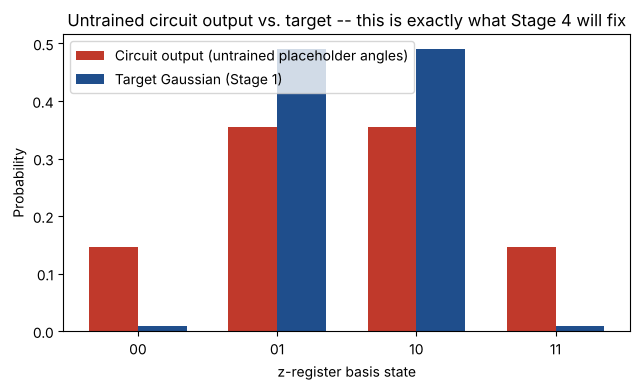

Untrained circuit output : [0.146 0.354 0.354 0.146]
Target Gaussian          : [0.009 0.491 0.491 0.009]

(As expected, these don't match yet -- closing this gap is exactly Stage 4's job.)


In [9]:
# ---- Marginal z-register distribution vs. the Stage 1 target Gaussian (untrained, for now) ----
def marginal_z_distribution(probs_dict, n_z_qubits):
    """Sums out the asset qubit to get P(z-register = b) for each b."""
    marg = np.zeros(2 ** n_z_qubits)
    for bitstring, p in probs_dict.items():
        z_bits = bitstring[1:]              # drop the leftmost (asset) character
        b = int(z_bits, 2)
        marg[b] += p
    return marg

marg_2q = marginal_z_distribution(probs_2q, n_z_qubits=2)

# Stage 1's target Gaussian histogram for the 2-qubit register (recomputed here for comparison)
z_grid_2q = discretize_z(2)
raw = np.exp(-(z_grid_2q ** 2) / 2)
target_2q = raw / raw.sum()

import matplotlib.pyplot as plt
labels = [format(b, '02b') for b in range(4)]
x = np.arange(4)
width = 0.35

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(x - width/2, marg_2q, width, label='Circuit output (untrained placeholder angles)', color='#c0392b')
ax.bar(x + width/2, target_2q, width, label='Target Gaussian (Stage 1)', color='#1f4e8c')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel('z-register basis state'); ax.set_ylabel('Probability')
ax.set_title('Untrained circuit output vs. target -- this is exactly what Stage 4 will fix')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/stage03_untrained_vs_target_preview.png', dpi=150)
plt.show()

print("Untrained circuit output :", np.round(marg_2q, 4))
print("Target Gaussian          :", np.round(target_2q, 4))
print("\n(As expected, these don't match yet -- closing this gap is exactly Stage 4's job.)")

In [10]:
import pickle

circuit_bundle = {
    "2_qubit": {"n_z_qubits": 2, "alpha_tilde": alpha_tilde_2q, "beta_tilde": beta_tilde_2q},
    "3_qubit": {"n_z_qubits": 3, "alpha_tilde": alpha_tilde_3q, "beta_tilde": beta_tilde_3q},
}

with open("results/circuit_design_params.json", "w") as f:
    json.dump(circuit_bundle, f, indent=2)

print("Saved -> results/circuit_design_params.json")
print(json.dumps(circuit_bundle, indent=2))
print("""
Note: we save the (alpha_tilde, beta_tilde, n_z_qubits) parameters rather than the
QuantumCircuit object itself -- Stage 4 rebuilds the circuit fresh from
build_gci_circuit(), which keeps every stage independently runnable and avoids
pickling Qiskit objects across notebook/version boundaries.
""")

Saved -> results/circuit_design_params.json
{
  "2_qubit": {
    "n_z_qubits": 2,
    "alpha_tilde": -0.12097876692308995,
    "beta_tilde": 0.7055160871779099
  },
  "3_qubit": {
    "n_z_qubits": 3,
    "alpha_tilde": -0.05184804296703855,
    "beta_tilde": 0.7055160871779099
  }
}

Note: we save the (alpha_tilde, beta_tilde, n_z_qubits) parameters rather than the
QuantumCircuit object itself -- Stage 4 rebuilds the circuit fresh from
build_gci_circuit(), which keeps every stage independently runnable and avoids
pickling Qiskit objects across notebook/version boundaries.

